# IMPROVE White-Style RT Calibration-Space Audit

This notebook is the IMPROVE-side companion to the SPARTAN `hips_offset_narrative.ipynb` White-style HIPS calibration-space plot.

## Working answer up front

The FED export currently available here does **not** include explicit HIPS field-blank rows. That means we cannot reproduce White et al.'s exact field-blank OLS calibration-line figure from FED alone. What we can do is the closest available analog:

1. Use the exported IMPROVE 635 nm **initial** RT readings (`RefI_635`, `TransI_635`) as the clean-filter reference relationship.
2. Plot active sample **minimum** and **final** readings (`RefM/TransM`, `RefF/TransF`) against that reference line.
3. Ask whether high-`fAbs` and ETAD-like IMPROVE filters occupy the same far-from-reference optical regime that SPARTAN Addis occupies relative to its blank line.
4. Tie that optical-regime view back to `fAbs` vs `ECf`, EC areal loading, OC/EC, FE/EC, and SOIL/EC.

## Important limitation

This is **not** a replacement for raw IMPROVE HIPS blank data. It is a FED-export diagnostic. If we need the exact White-style blank calibration plot, the next request to Alex/Cena should ask for the row-level HIPS blank records or the same raw file type White used for Figure 2.

## 1. Setup

In [1]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 160)

REPO_ROOT = Path('/Users/ahmadjalil/github/aethmodular').resolve()
NOTEBOOK_DIR = REPO_ROOT / 'research' / 'improve_hips_offset'
OUTPUT_DIR = NOTEBOOK_DIR / 'output' / 'white_style_rt_calibration_space'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMPROVE_DIR = Path(
    '/Users/ahmadjalil/Library/CloudStorage/GoogleDrive-ahzs645@gmail.com/My Drive/University/Research/Grad/UC Davis Ann/NASA MAIA/Data/Improve'
).resolve()

SPARTAN_FILTER_PATH = REPO_ROOT / 'research' / 'ftir_hips_chem' / 'Filter Data' / 'unified_filter_dataset.pkl'

ETAD_FABS_LOW = 28.09
ETAD_FABS_HIGH = 85.85
HIGH_TAIL_FABS = 70.0
AREA_OPTIONS_CM2 = [2.2, 3.53, 4.0]
DEFAULT_AREA_CM2 = 3.53
RNG = np.random.default_rng(20260422)

assert IMPROVE_DIR.exists(), IMPROVE_DIR
assert SPARTAN_FILTER_PATH.exists(), SPARTAN_FILTER_PATH

print(f'Notebook dir: {NOTEBOOK_DIR}')
print(f'Output dir:   {OUTPUT_DIR}')
print(f'IMPROVE dir:  {IMPROVE_DIR}')

Notebook dir: /Users/ahmadjalil/github/aethmodular/research/improve_hips_offset
Output dir:   /Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/output/white_style_rt_calibration_space
IMPROVE dir:  /Users/ahmadjalil/Library/CloudStorage/GoogleDrive-ahzs645@gmail.com/My Drive/University/Research/Grad/UC Davis Ann/NASA MAIA/Data/Improve


## 2. Load FED workbooks

The FED Excel files are discovered by their `Data` sheet columns so this notebook does not depend on the random FED export filenames.

`-999` values are treated as missing. The row-level data sheet in this pull has value columns only; it does not include explicit per-row status/provider flag columns.

In [2]:
def read_fed_data_workbook(path: Path) -> tuple[pd.DataFrame, dict[str, pd.DataFrame]]:
    """Read a FED workbook by finding the header row in the Data sheet."""
    probe = pd.read_excel(path, sheet_name='Data', header=None, nrows=80)
    header_row = None
    for idx, row in probe.iterrows():
        values = {str(v).strip() for v in row.dropna().tolist()}
        if {'Dataset', 'SiteCode', 'Date'}.issubset(values):
            header_row = int(idx)
            break
    if header_row is None:
        raise ValueError(f'Could not find FED Data header row in {path}')

    data = pd.read_excel(path, sheet_name='Data', header=header_row)
    data = data.replace(-999, np.nan).replace('-999', np.nan)
    for col in data.columns:
        if col.endswith('_Val') or col in ['POC', 'AuxID']:
            data[col] = pd.to_numeric(data[col], errors='coerce')
    data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

    meta = {}
    xl = pd.ExcelFile(path)
    for sheet in ['Sites', 'Parameters', 'Status Flags', 'Provider Flags', 'Dataset History']:
        if sheet in xl.sheet_names:
            meta[sheet] = pd.read_excel(path, sheet_name=sheet)
    return data, meta


def workbook_with_columns(required: set[str]) -> Path:
    candidates = []
    for path in sorted(IMPROVE_DIR.glob('*.xlsx')):
        try:
            preview = pd.read_excel(path, sheet_name='Data', nrows=0)
        except Exception:
            continue
        cols = set(map(str, preview.columns))
        if required.issubset(cols):
            candidates.append(path)
    if len(candidates) != 1:
        raise FileNotFoundError(f'Expected one workbook with {required}, found: {candidates}')
    return candidates[0]

chem_path = workbook_with_columns({'ECf_Val', 'OCf_Val', 'fAbs_Val'})
rt_path = workbook_with_columns({'RefI_635_Val', 'TransI_635_Val', 'RefM_635_Val', 'TransM_635_Val'})

chem, chem_meta = read_fed_data_workbook(chem_path)
rt, rt_meta = read_fed_data_workbook(rt_path)

print('Chem workbook:', chem_path.name, chem.shape)
print('RT workbook:  ', rt_path.name, rt.shape)
print('\nChem columns:')
print(', '.join(chem.columns.astype(str)))
print('\nRT columns:')
print(', '.join(rt.columns.astype(str)))

flag_like_cols = [c for c in list(chem.columns) + list(rt.columns) if re.search('flag|status|valid|qual', str(c), re.I)]
print('\nRow-level flag/status-like columns in Data sheets:', flag_like_cols if flag_like_cols else 'none')

Chem workbook: ahzs645_20260422_122542_N0100.xlsx (626518, 13)
RT workbook:   ahzs645_20260422_122246_x0Ivu.xlsx (185618, 11)

Chem columns:
Dataset, SiteCode, POC, Date, AuxID, ECf_Val, OCf_Val, fAbs_Val, FlowRate_Val, FEf_Val, MF_Val, SampDur_Val, SOILf_Val

RT columns:
Dataset, SiteCode, POC, Date, AuxID, RefF_635_Val, TransF_635_Val, RefI_635_Val, TransI_635_Val, RefM_635_Val, TransM_635_Val

Row-level flag/status-like columns in Data sheets: none


## 3. Join chemistry and RT, then define comparable regimes

The join key is the FED sample key: `Dataset`, `SiteCode`, `POC`, `Date`, and `AuxID`.

For loading comparisons, IMPROVE concentration is converted to deposited EC mass using:

`volume_m3 = FlowRate_Val * SampDur_Val / 1000`

assuming `FlowRate_Val` is L/min and `SampDur_Val` is minutes. Areal loading is reported as a sensitivity using 2.2, 3.53, and 4.0 cm2 because the exact active area depends on IMPROVE sampler/module history.

In [3]:
KEY = ['Dataset', 'SiteCode', 'POC', 'Date', 'AuxID']
rt_cols = KEY + [
    'RefF_635_Val', 'TransF_635_Val', 'RefI_635_Val', 'TransI_635_Val', 'RefM_635_Val', 'TransM_635_Val'
]
chem_cols = KEY + ['ECf_Val', 'OCf_Val', 'fAbs_Val', 'FlowRate_Val', 'SampDur_Val', 'MF_Val', 'FEf_Val', 'SOILf_Val']


def collapse_duplicate_sample_keys(df: pd.DataFrame, value_cols: list[str], label: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Collapse rare duplicate FED sample keys by first non-missing value per column."""
    dup_mask = df.duplicated(KEY, keep=False)
    duplicate_groups = (
        df.loc[dup_mask, KEY]
        .drop_duplicates()
        .assign(source=label)
        .reset_index(drop=True)
    )
    if not dup_mask.any():
        return df[KEY + value_cols].copy(), duplicate_groups

    def first_valid(series: pd.Series):
        non_missing = series.dropna()
        return non_missing.iloc[0] if len(non_missing) else np.nan

    collapsed = (
        df[KEY + value_cols]
        .groupby(KEY, as_index=False, dropna=False)
        .agg({col: first_valid for col in value_cols})
    )
    return collapsed, duplicate_groups

chem_dedup, chem_duplicate_keys = collapse_duplicate_sample_keys(chem, [c for c in chem_cols if c not in KEY], 'chemistry')
rt_dedup, rt_duplicate_keys = collapse_duplicate_sample_keys(rt, [c for c in rt_cols if c not in KEY], 'rt')

duplicate_key_audit = pd.concat([chem_duplicate_keys, rt_duplicate_keys], ignore_index=True)
joined = chem_dedup.merge(rt_dedup, on=KEY, how='inner', validate='one_to_one')

print(f'Collapsed chemistry duplicate keys: {len(chem_duplicate_keys)}')
print(f'Collapsed RT duplicate keys: {len(rt_duplicate_keys)}')

# Attach site metadata if available.
sites = chem_meta.get('Sites')
if sites is not None and {'Code', 'Site'}.issubset(sites.columns):
    site_cols = [c for c in ['Code', 'Site', 'Country', 'State', 'County', 'Latitude', 'Longitude', 'Elevation'] if c in sites.columns]
    joined = joined.merge(sites[site_cols].rename(columns={'Code': 'SiteCode', 'Site': 'SiteName'}), on='SiteCode', how='left')
else:
    joined['SiteName'] = joined['SiteCode']

numeric_cols = [c for c in joined.columns if c.endswith('_Val')]
for col in numeric_cols:
    joined[col] = pd.to_numeric(joined[col], errors='coerce')

joined['year'] = joined['Date'].dt.year
joined['month'] = joined['Date'].dt.month
joined['doy'] = joined['Date'].dt.dayofyear

joined['volume_m3'] = joined['FlowRate_Val'] * joined['SampDur_Val'] / 1000.0
joined['EC_loading_ug'] = joined['ECf_Val'] * joined['volume_m3']
joined['OC_loading_ug'] = joined['OCf_Val'] * joined['volume_m3']
joined['MF_loading_ug'] = joined['MF_Val'] * joined['volume_m3']
for area in AREA_OPTIONS_CM2:
    label = str(area).replace('.', 'p')
    joined[f'EC_loading_ug_cm2_{label}'] = joined['EC_loading_ug'] / area
    joined[f'MF_loading_ug_cm2_{label}'] = joined['MF_loading_ug'] / area

joined['OC_EC'] = joined['OCf_Val'] / joined['ECf_Val']
joined['FE_EC'] = joined['FEf_Val'] / joined['ECf_Val']
joined['SOIL_EC'] = joined['SOILf_Val'] / joined['ECf_Val']
joined['BC_frac_proxy'] = joined['ECf_Val'] / joined['MF_Val']

# Basic validity layer: keep positive chemistry and positive RT signals.
rt_required = ['RefI_635_Val', 'TransI_635_Val', 'RefM_635_Val', 'TransM_635_Val', 'RefF_635_Val', 'TransF_635_Val']
chem_required = ['ECf_Val', 'OCf_Val', 'fAbs_Val', 'FlowRate_Val', 'SampDur_Val']
valid = joined.dropna(subset=chem_required + rt_required).copy()
valid = valid[
    (valid['ECf_Val'] > 0) &
    (valid['OCf_Val'] >= 0) &
    (valid['fAbs_Val'] > 0) &
    (valid['FlowRate_Val'] > 0) &
    (valid['SampDur_Val'] > 0)
].copy()
for col in rt_required:
    valid = valid[valid[col] > 0]

# Trim impossible-looking RT values only for the calibration-space fits and plots.
rt_fit_mask = pd.Series(True, index=valid.index)
for col in rt_required:
    lo, hi = valid[col].quantile([0.001, 0.999])
    rt_fit_mask &= valid[col].between(lo, hi)
valid['rt_plot_valid'] = rt_fit_mask

# Local ETAD/SPARTAN reference regime from unified_filter_dataset.pkl.
df_long = pd.read_pickle(SPARTAN_FILTER_PATH)
df_long['SampleDate'] = pd.to_datetime(df_long['SampleDate'], errors='coerce')
spartan_wide = (
    df_long[df_long['Parameter'].isin(['EC_ftir', 'HIPS_Fabs'])]
    .pivot_table(index=['Site', 'FilterId', 'SampleDate', 'FilterType', 'DepositArea_cm2', 'Volume_m3'],
                 columns='Parameter', values='Concentration', aggfunc='first')
    .reset_index()
)
spartan_wide.columns.name = None
etad = spartan_wide[(spartan_wide['Site'] == 'ETAD') & (spartan_wide['FilterType'] == 'PM2.5')].dropna(subset=['EC_ftir', 'HIPS_Fabs', 'Volume_m3', 'DepositArea_cm2']).copy()
etad['EC_loading_ug'] = etad['EC_ftir'] * etad['Volume_m3']
etad['EC_loading_ug_cm2'] = etad['EC_loading_ug'] / etad['DepositArea_cm2']

etad_ref = {
    'fAbs_min': etad['HIPS_Fabs'].min(),
    'fAbs_p05': etad['HIPS_Fabs'].quantile(0.05),
    'fAbs_median': etad['HIPS_Fabs'].median(),
    'fAbs_p95': etad['HIPS_Fabs'].quantile(0.95),
    'fAbs_max': etad['HIPS_Fabs'].max(),
    'EC_loading_ug_p05': etad['EC_loading_ug'].quantile(0.05),
    'EC_loading_ug_median': etad['EC_loading_ug'].median(),
    'EC_loading_ug_p95': etad['EC_loading_ug'].quantile(0.95),
    'EC_loading_ug_cm2_p05': etad['EC_loading_ug_cm2'].quantile(0.05),
    'EC_loading_ug_cm2_median': etad['EC_loading_ug_cm2'].median(),
    'EC_loading_ug_cm2_p95': etad['EC_loading_ug_cm2'].quantile(0.95),
}

valid['group_all_valid'] = True
valid['group_etad_fabs'] = valid['fAbs_Val'].between(ETAD_FABS_LOW, ETAD_FABS_HIGH)
valid['group_high_tail_ge70'] = valid['fAbs_Val'] >= HIGH_TAIL_FABS
valid['group_etad_ec_loading'] = valid['EC_loading_ug_cm2_3p53'].between(
    etad_ref['EC_loading_ug_cm2_p05'], etad_ref['EC_loading_ug_cm2_p95']
)
valid['group_etad_fabs_loading'] = valid['group_etad_fabs'] & valid['group_etad_ec_loading']
valid['group_smoke_like_proxy'] = (
    valid['group_etad_ec_loading'] &
    (valid['OC_EC'] >= 5) &
    (valid['SOIL_EC'].fillna(0) <= valid['SOIL_EC'].quantile(0.75)) &
    (valid['FE_EC'].fillna(0) <= valid['FE_EC'].quantile(0.75))
)

inventory = pd.DataFrame({
    'metric': [
        'Joined chemistry + RT rows', 'Valid positive chemistry + RT rows', 'Sites in valid table',
        'Date start', 'Date end', 'ETAD HIPS_Fabs min', 'ETAD HIPS_Fabs median', 'ETAD HIPS_Fabs max',
        'ETAD EC loading median ug/cm2'
    ],
    'value': [
        len(joined), len(valid), valid['SiteCode'].nunique(), valid['Date'].min().date(), valid['Date'].max().date(),
        etad_ref['fAbs_min'], etad_ref['fAbs_median'], etad_ref['fAbs_max'], etad_ref['EC_loading_ug_cm2_median']
    ]
})

group_counts = pd.DataFrame({
    'group': ['all_valid', 'ETAD-like fAbs', 'fAbs >= 70', 'ETAD EC loading p05-p95', 'ETAD fAbs + EC loading', 'smoke-like proxy'],
    'n': [
        len(valid), int(valid['group_etad_fabs'].sum()), int(valid['group_high_tail_ge70'].sum()),
        int(valid['group_etad_ec_loading'].sum()), int(valid['group_etad_fabs_loading'].sum()),
        int(valid['group_smoke_like_proxy'].sum())
    ],
    'sites': [
        valid['SiteCode'].nunique(), valid.loc[valid['group_etad_fabs'], 'SiteCode'].nunique(),
        valid.loc[valid['group_high_tail_ge70'], 'SiteCode'].nunique(), valid.loc[valid['group_etad_ec_loading'], 'SiteCode'].nunique(),
        valid.loc[valid['group_etad_fabs_loading'], 'SiteCode'].nunique(), valid.loc[valid['group_smoke_like_proxy'], 'SiteCode'].nunique()
    ]
})

display(inventory)
display(group_counts)

Collapsed chemistry duplicate keys: 5
Collapsed RT duplicate keys: 0


,metric,value
0,Joined chemistry + RT rows,185614
1,Valid positive chemistry + RT rows,143777
2,Sites in valid table,167
3,Date start,2016-01-01
4,Date end,2025-07-30
5,ETAD HIPS_Fabs min,28.085699
6,ETAD HIPS_Fabs median,47.132129
7,ETAD HIPS_Fabs max,85.852735
8,ETAD EC loading median ug/cm2,9.491196


,group,n,sites
0,all_valid,143777,167
1,ETAD-like fAbs,41,19
2,fAbs >= 70,1,1
3,ETAD EC loading p05-p95,6265,158
4,ETAD fAbs + EC loading,18,11
5,smoke-like proxy,2156,157


### Interpretation

This FED pull covers a large IMPROVE RT subset, but the RT parameters are available only for the years present in the RT workbook. The comparison groups are intentionally broader than the exact ETAD `fAbs` range because the exact high-`fAbs` tail is sparse.

## 4. Initial RT line as the FED analog to a blank calibration line

White et al.'s exact plot uses field blanks. FED does not export those blank rows here, so this section fits the initial clean-filter relationship:

`TransI_635 = b0 + b1 * RefI_635`

Then it asks where the measured minimum/final readings sit relative to that initial-reference line.

In [4]:
def ols_stats(df: pd.DataFrame, x_col: str, y_col: str) -> dict:
    pair = df[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(pair) < 3:
        return {'n': len(pair), 'slope': np.nan, 'intercept': np.nan, 'r2': np.nan}
    x = pair[x_col].to_numpy(float)
    y = pair[y_col].to_numpy(float)
    slope, intercept = np.polyfit(x, y, 1)
    r2 = float(np.corrcoef(x, y)[0, 1] ** 2)
    return {'n': len(pair), 'slope': slope, 'intercept': intercept, 'r2': r2}

fit_df = valid[valid['rt_plot_valid']].copy()
# Fit after light trimming of extreme initial readings.
for col in ['RefI_635_Val', 'TransI_635_Val']:
    lo, hi = fit_df[col].quantile([0.005, 0.995])
    fit_df = fit_df[fit_df[col].between(lo, hi)]

initial_fit = ols_stats(fit_df, 'RefI_635_Val', 'TransI_635_Val')
B1 = initial_fit['slope']
B0 = initial_fit['intercept']

for prefix in ['M', 'F']:
    ref_col = f'Ref{prefix}_635_Val'
    trans_col = f'Trans{prefix}_635_Val'
    pred_col = f'Trans{prefix}_expected_from_initial_line'
    deficit_col = f'Trans{prefix}_deficit'
    frac_col = f'Trans{prefix}_deficit_frac'
    valid[pred_col] = B0 + B1 * valid[ref_col]
    valid[deficit_col] = valid[pred_col] - valid[trans_col]
    valid[frac_col] = valid[deficit_col] / valid[pred_col]

valid['TransM_over_TransI'] = valid['TransM_635_Val'] / valid['TransI_635_Val']
valid['RefM_over_RefI'] = valid['RefM_635_Val'] / valid['RefI_635_Val']
valid['rt_tau_proxy_M'] = -np.log(valid['TransM_over_TransI'])
valid.loc[~np.isfinite(valid['rt_tau_proxy_M']), 'rt_tau_proxy_M'] = np.nan
valid['double_pass_proxy'] = valid['TransM_over_TransI'] / valid['RefM_over_RefI']

calibration_summary = pd.DataFrame([{
    'reference': 'Initial RT line, trimmed OLS',
    'n': initial_fit['n'],
    'intercept_b0': B0,
    'slope_b1': B1,
    'R2': initial_fit['r2'],
    'date_start': valid['Date'].min(),
    'date_end': valid['Date'].max(),
    'note': 'FED analog; not a field-blank regression'
}])

group_defs = {
    'all_valid': valid['group_all_valid'],
    'ETAD-like_fAbs': valid['group_etad_fabs'],
    'fAbs_ge70': valid['group_high_tail_ge70'],
    'ETAD_loading': valid['group_etad_ec_loading'],
    'ETAD_fAbs_loading': valid['group_etad_fabs_loading'],
    'smoke_like_proxy': valid['group_smoke_like_proxy'],
}

rt_group_rows = []
for name, mask in group_defs.items():
    g = valid[mask].copy()
    if len(g) == 0:
        continue
    rt_group_rows.append({
        'group': name,
        'n': len(g),
        'sites': g['SiteCode'].nunique(),
        'fAbs_median': g['fAbs_Val'].median(),
        'ECf_median': g['ECf_Val'].median(),
        'EC_loading_ug_cm2_median_3p53': g['EC_loading_ug_cm2_3p53'].median(),
        'OC_EC_median': g['OC_EC'].median(),
        'TransM_deficit_frac_median': g['TransM_deficit_frac'].median(),
        'TransM_deficit_frac_p95': g['TransM_deficit_frac'].quantile(0.95),
        'rt_tau_proxy_M_median': g['rt_tau_proxy_M'].median(),
        'TransM_over_TransI_median': g['TransM_over_TransI'].median(),
        'RefM_over_RefI_median': g['RefM_over_RefI'].median(),
    })
rt_group_summary = pd.DataFrame(rt_group_rows)

calibration_summary.to_csv(OUTPUT_DIR / 'improve_initial_rt_line_fit.csv', index=False)
rt_group_summary.to_csv(OUTPUT_DIR / 'improve_rt_group_summary.csv', index=False)
valid.to_pickle(OUTPUT_DIR / 'improve_joined_rt_chem_with_diagnostics.pkl')

print('Initial-reference line:')
display(calibration_summary.round({'intercept_b0': 3, 'slope_b1': 4, 'R2': 3}))
print('RT group summary:')
display(rt_group_summary.round(3))

Initial-reference line:


,reference,n,intercept_b0,slope_b1,R2,date_start,date_end,note
0,"Initial RT line, trimmed OLS",139853,64.925,0.3069,0.238,2016-01-01,2025-07-30,FED analog; not a field-blank regression


RT group summary:


,group,n,sites,fAbs_median,ECf_median,EC_loading_ug_cm2_median_3p53,OC_EC_median,TransM_deficit_frac_median,TransM_deficit_frac_p95,rt_tau_proxy_M_median,TransM_over_TransI_median,RefM_over_RefI_median
0,all_valid,143777,167,1.290,0.105,0.908,5.649,0.547,0.954,0.806,0.447,0.853
1,ETAD-like_fAbs,41,19,33.130,2.567,20.186,2.663,0.992,0.999,1.265,0.282,0.935
2,fAbs_ge70,1,1,90.260,4.946,30.340,2.433,0.999,0.999,2.665,0.070,0.996
3,ETAD_loading,6265,158,7.120,0.771,6.625,3.751,0.936,0.995,1.793,0.166,0.858
4,ETAD_fAbs_loading,18,11,32.010,1.997,16.120,4.358,0.973,0.999,1.192,0.305,0.914
5,smoke_like_proxy,2156,157,6.055,0.755,6.447,8.022,0.949,0.997,2.280,0.102,0.775


## 5. White-style RT calibration-space plots

Panel A is the closest FED analog to White et al.'s calibration-space figure: initial readings define the clean-filter reference line; measured minimum readings show where loaded filters fall.

Panel B shows the same idea as a deficit from the initial-reference line. Panel C ties the optical position back to `fAbs` vs `ECf`.

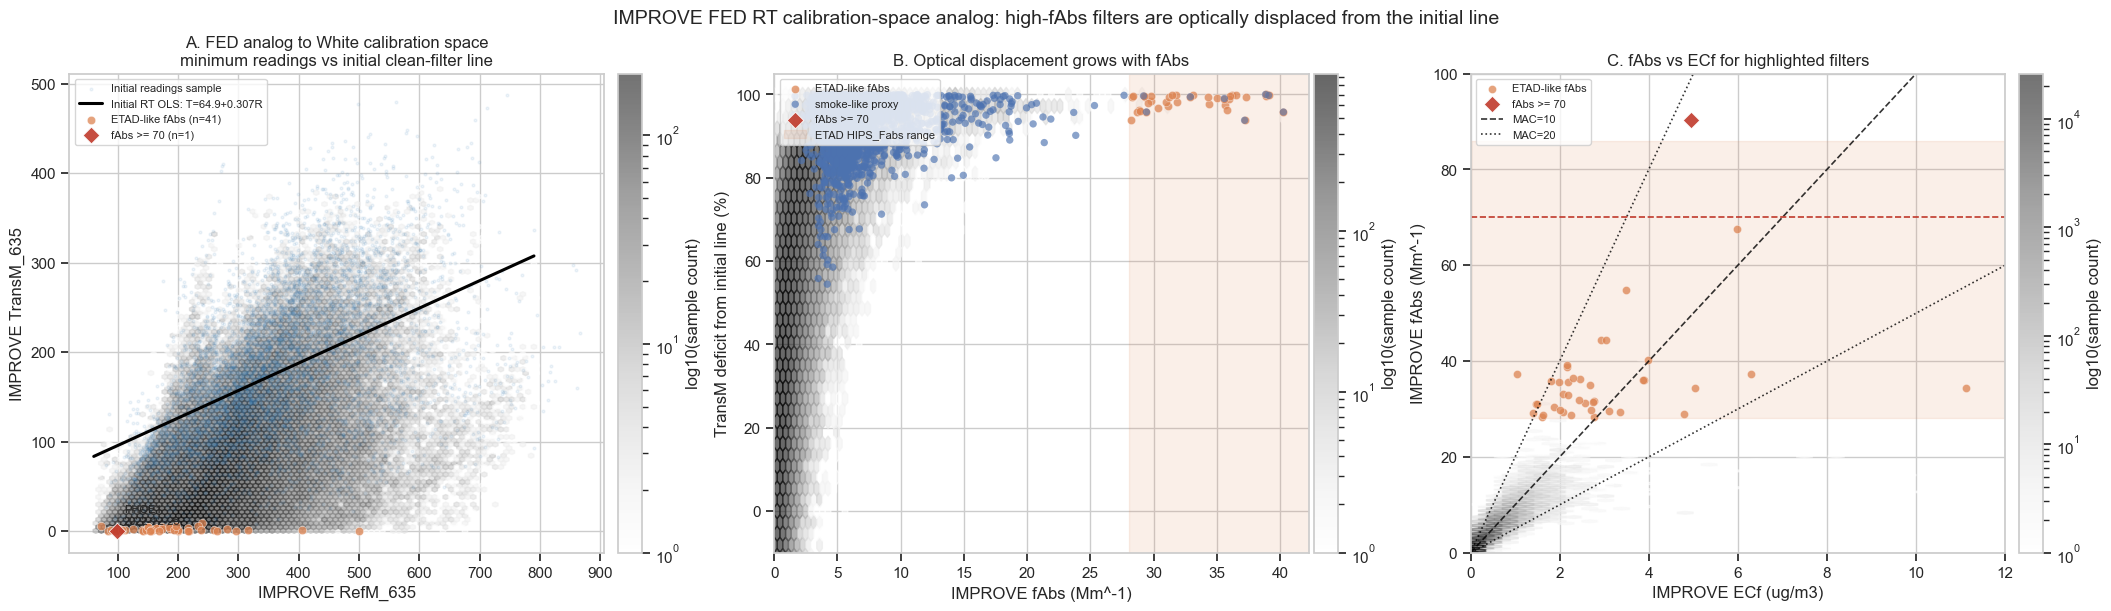

In [5]:
plot_df = valid[valid['rt_plot_valid']].copy()
highlight_df = valid.dropna(subset=['RefM_635_Val', 'TransM_635_Val', 'fAbs_Val', 'ECf_Val']).copy()
# Keep a manageable trimmed background, but never trim highlighted candidates.
bg = plot_df.sample(n=min(120000, len(plot_df)), random_state=42) if len(plot_df) > 120000 else plot_df
etad_like = highlight_df[highlight_df['group_etad_fabs']]
high_tail = highlight_df[highlight_df['group_high_tail_ge70']]
smoke_like = highlight_df[highlight_df['group_smoke_like_proxy']]

x_min = min(plot_df['RefM_635_Val'].quantile(0.001), highlight_df['RefM_635_Val'].quantile(0.001))
x_max = max(plot_df['RefM_635_Val'].quantile(0.999), etad_like['RefM_635_Val'].max(), high_tail['RefM_635_Val'].max())
x_line = np.linspace(max(0, x_min * 0.95), x_max * 1.05, 300)
y_line = B0 + B1 * x_line

fig, axes = plt.subplots(1, 3, figsize=(21, 6), constrained_layout=True)

ax = axes[0]
# Density for all minimum readings.
hb = ax.hexbin(bg['RefM_635_Val'], bg['TransM_635_Val'], gridsize=80, bins='log', mincnt=1, cmap='Greys', alpha=0.55)
ax.scatter(bg['RefI_635_Val'].sample(n=min(6000, len(bg)), random_state=3),
           bg['TransI_635_Val'].sample(n=min(6000, len(bg)), random_state=3),
           s=4, color='#377eb8', alpha=0.08, label='Initial readings sample')
ax.plot(x_line, y_line, color='black', lw=2.2,
        label=f'Initial RT OLS: T={B0:.1f}+{B1:.3f}R')
ax.scatter(etad_like['RefM_635_Val'], etad_like['TransM_635_Val'], s=36, color='#dd8452',
           alpha=0.75, edgecolor='white', linewidth=0.35, label=f'ETAD-like fAbs (n={len(etad_like)})')
ax.scatter(high_tail['RefM_635_Val'], high_tail['TransM_635_Val'], s=72, color='#c0392b',
           marker='D', alpha=0.9, edgecolor='white', linewidth=0.6, label=f'fAbs >= 70 (n={len(high_tail)})')
for _, row in high_tail.nlargest(6, 'fAbs_Val').iterrows():
    ax.annotate(f"{row['SiteCode']}\n{row['Date'].date()}",
                (row['RefM_635_Val'], row['TransM_635_Val']), xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.set_xlabel('IMPROVE RefM_635')
ax.set_ylabel('IMPROVE TransM_635')
ax.set_title('A. FED analog to White calibration space\nminimum readings vs initial clean-filter line')
ax.legend(loc='upper left', fontsize=8, frameon=True)
cb = fig.colorbar(hb, ax=ax, pad=0.01)
cb.set_label('log10(sample count)')

ax = axes[1]
hb2 = ax.hexbin(plot_df['fAbs_Val'], plot_df['TransM_deficit_frac'] * 100,
                gridsize=90, bins='log', mincnt=1, cmap='Greys', alpha=0.6)
ax.scatter(etad_like['fAbs_Val'], etad_like['TransM_deficit_frac'] * 100, s=35, color='#dd8452',
           alpha=0.75, edgecolor='white', linewidth=0.35, label='ETAD-like fAbs')
ax.scatter(smoke_like['fAbs_Val'], smoke_like['TransM_deficit_frac'] * 100, s=28, color='#4c72b0',
           alpha=0.65, edgecolor='none', label='smoke-like proxy')
ax.scatter(high_tail['fAbs_Val'], high_tail['TransM_deficit_frac'] * 100, s=70, color='#c0392b',
           marker='D', alpha=0.9, edgecolor='white', linewidth=0.6, label='fAbs >= 70')
ax.axvspan(ETAD_FABS_LOW, ETAD_FABS_HIGH, color='#dd8452', alpha=0.13, label='ETAD HIPS_Fabs range')
ax.axvline(HIGH_TAIL_FABS, color='#c0392b', ls='--', lw=1.2)
ax.set_xlim(0, min(max(110, plot_df['fAbs_Val'].quantile(0.9995)), plot_df['fAbs_Val'].max() * 1.05))
ax.set_xlabel('IMPROVE fAbs (Mm^-1)')
ax.set_ylabel('TransM deficit from initial line (%)')
ax.set_ylim(-10, 105)
ax.set_title('B. Optical displacement grows with fAbs')
ax.legend(loc='upper left', fontsize=8, frameon=True)
cb2 = fig.colorbar(hb2, ax=ax, pad=0.01)
cb2.set_label('log10(sample count)')

ax = axes[2]
base = plot_df[(plot_df['ECf_Val'] > 0) & (plot_df['fAbs_Val'] > 0)]
hb3 = ax.hexbin(base['ECf_Val'], base['fAbs_Val'], gridsize=80, bins='log', mincnt=1, cmap='Greys', alpha=0.55)
ax.scatter(etad_like['ECf_Val'], etad_like['fAbs_Val'], s=34, color='#dd8452',
           alpha=0.75, edgecolor='white', linewidth=0.35, label='ETAD-like fAbs')
ax.scatter(high_tail['ECf_Val'], high_tail['fAbs_Val'], s=70, color='#c0392b',
           marker='D', alpha=0.9, edgecolor='white', linewidth=0.6, label='fAbs >= 70')
# Reference MAC lines through origin.
xmax = min(max(12, base['ECf_Val'].quantile(0.999)), 60)
xref = np.linspace(0, xmax, 200)
for mac in [5, 10, 20]:
    ax.plot(xref, mac * xref, lw=1.2, ls=':' if mac != 10 else '--', color='black', alpha=0.8,
            label=f'MAC={mac}' if mac in [10, 20] else None)
ax.axhspan(ETAD_FABS_LOW, ETAD_FABS_HIGH, color='#dd8452', alpha=0.13)
ax.axhline(HIGH_TAIL_FABS, color='#c0392b', ls='--', lw=1.2)
ax.set_xlim(0, xmax)
ax.set_ylim(0, max(100, min(base['fAbs_Val'].quantile(0.9995), 140)))
ax.set_xlabel('IMPROVE ECf (ug/m3)')
ax.set_ylabel('IMPROVE fAbs (Mm^-1)')
ax.set_title('C. fAbs vs ECf for highlighted filters')
ax.legend(loc='upper left', fontsize=8, frameon=True)
cb3 = fig.colorbar(hb3, ax=ax, pad=0.01)
cb3.set_label('log10(sample count)')

fig.suptitle('IMPROVE FED RT calibration-space analog: high-fAbs filters are optically displaced from the initial line', fontsize=14)
fig.savefig(OUTPUT_DIR / 'improve_white_style_rt_calibration_space.png', dpi=220, bbox_inches='tight')
plt.show()

## 6. Site panels for the most relevant high-fAbs IMPROVE sites

These panels answer Ann's practical question: are the ETAD-like/high-tail points scattered across sites and dates, or concentrated in specific sites/events?

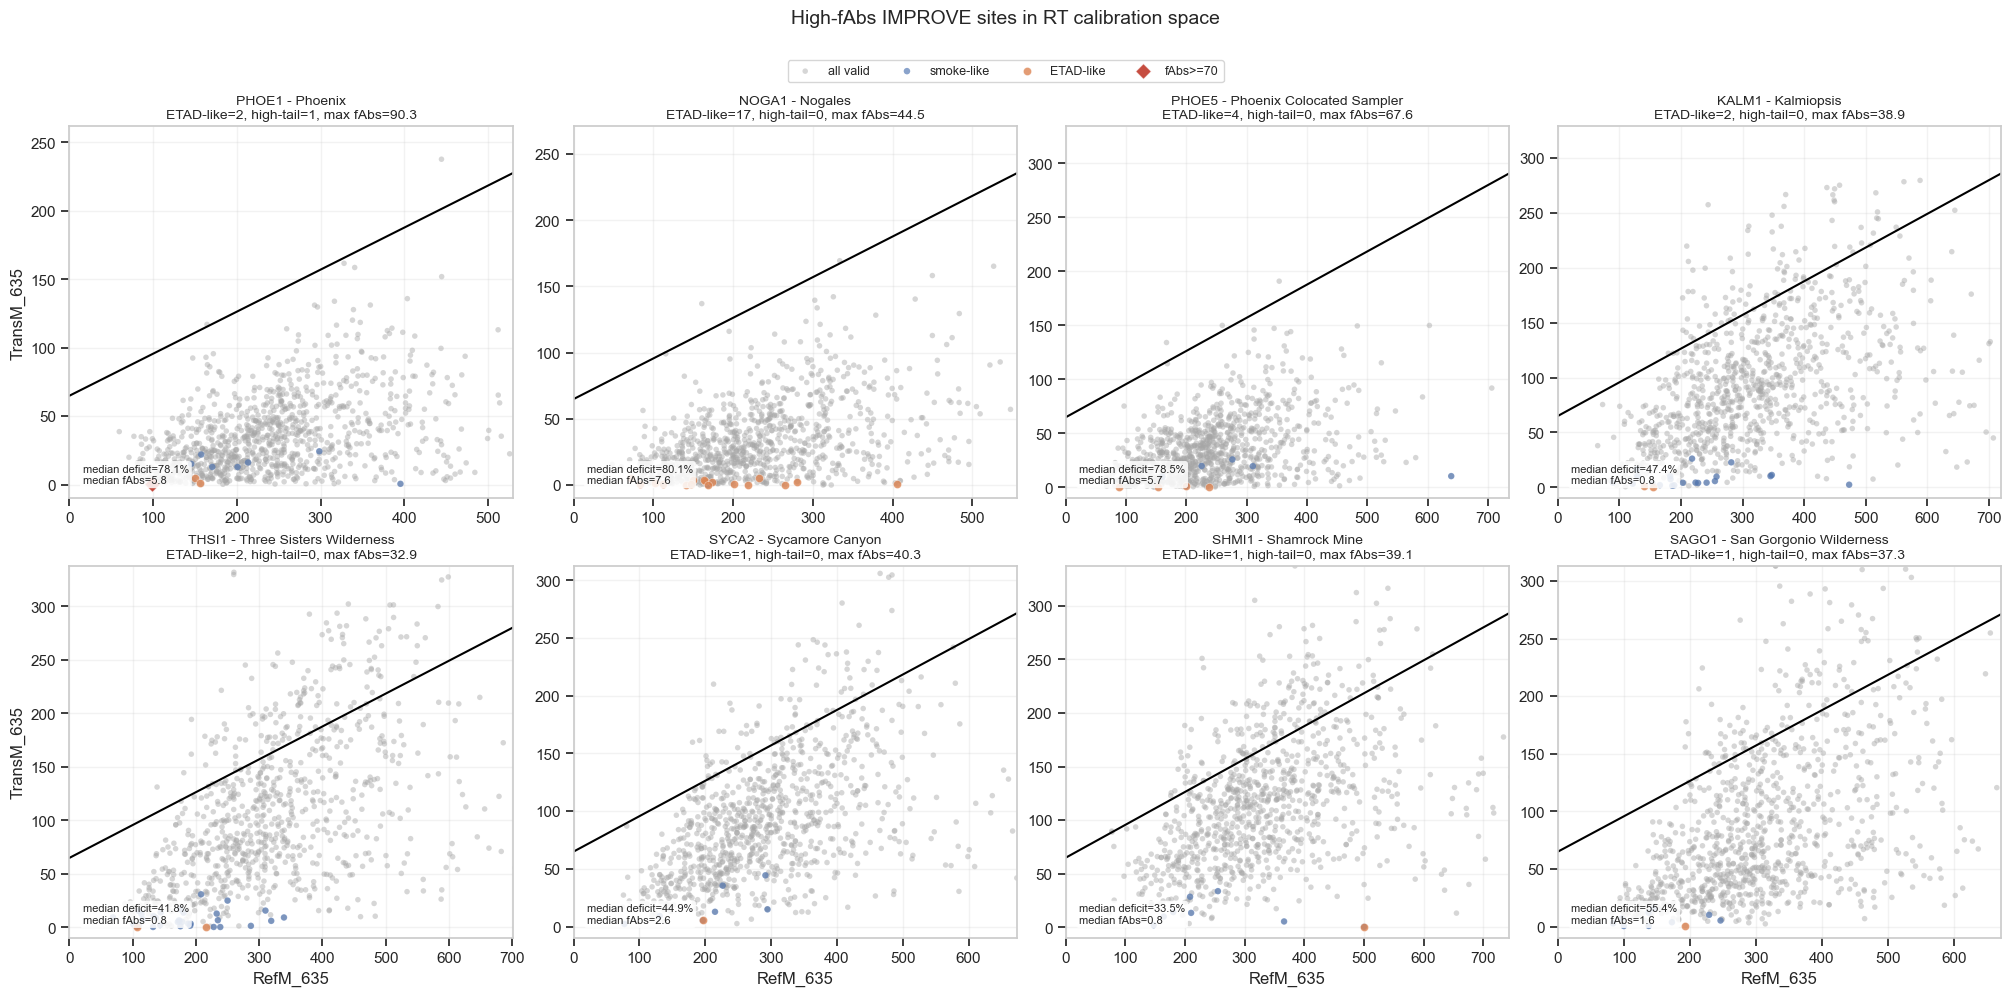

Top relevant sites:


,SiteCode,relevance,etad_like,high_tail,fAbs_max,n
0,PHOE1,12,2,1,90.26,1027
1,NOGA1,18,17,0,44.48,947
2,PHOE5,10,4,0,67.58,998
3,KALM1,23,2,0,38.91,963
4,THSI1,34,2,0,32.91,855
5,SYCA2,8,1,0,40.27,941
6,SHMI1,9,1,0,39.10,951
7,SAGO1,10,1,0,37.32,983


In [6]:
# Choose sites with the most ETAD-like/high-tail optical relevance.
site_panel_df = valid.dropna(subset=['RefM_635_Val', 'TransM_635_Val', 'fAbs_Val', 'ECf_Val']).copy()
site_rank = (
    site_panel_df.assign(relevance=site_panel_df['group_etad_fabs'].astype(int) + 3 * site_panel_df['group_high_tail_ge70'].astype(int) + site_panel_df['group_smoke_like_proxy'].astype(int))
    .groupby('SiteCode')
    .agg(relevance=('relevance', 'sum'), etad_like=('group_etad_fabs', 'sum'), high_tail=('group_high_tail_ge70', 'sum'),
         fAbs_max=('fAbs_Val', 'max'), n=('SiteCode', 'size'))
    .sort_values(['high_tail', 'etad_like', 'fAbs_max'], ascending=False)
    .head(8)
)
selected_sites = site_rank.index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(20, 9), sharex=False, sharey=False, constrained_layout=True)
for ax, site in zip(axes.ravel(), selected_sites):
    g = site_panel_df[site_panel_df['SiteCode'] == site].copy()
    ax.scatter(g['RefM_635_Val'], g['TransM_635_Val'], s=16, color='0.65', alpha=0.45, edgecolor='none', label='all valid')
    ge = g[g['group_etad_fabs']]
    gh = g[g['group_high_tail_ge70']]
    gs = g[g['group_smoke_like_proxy']]
    ax.scatter(gs['RefM_635_Val'], gs['TransM_635_Val'], s=22, color='#4c72b0', alpha=0.65, edgecolor='none', label='smoke-like')
    ax.scatter(ge['RefM_635_Val'], ge['TransM_635_Val'], s=34, color='#dd8452', alpha=0.8, edgecolor='white', linewidth=0.3, label='ETAD-like')
    ax.scatter(gh['RefM_635_Val'], gh['TransM_635_Val'], s=62, color='#c0392b', marker='D', alpha=0.9, edgecolor='white', linewidth=0.5, label='fAbs>=70')
    highlight_g = pd.concat([ge, gh, gs], ignore_index=True)
    x_hi = max(g['RefM_635_Val'].quantile(0.98), highlight_g['RefM_635_Val'].max() if len(highlight_g) else 0)
    x_hi = min(max(250, x_hi * 1.15), 900)
    y_hi = max(g['TransM_635_Val'].quantile(0.98), highlight_g['TransM_635_Val'].max() if len(highlight_g) else 0, B0 + B1 * x_hi)
    y_hi = min(max(120, y_hi * 1.15), 650)
    x_local = np.linspace(0, x_hi, 150)
    ax.plot(x_local, B0 + B1 * x_local, color='black', lw=1.5)
    ax.set_xlim(0, x_hi)
    ax.set_ylim(-10, y_hi)
    site_name = g['SiteName'].dropna().iloc[0] if g['SiteName'].notna().any() else site
    ax.set_title(f'{site} - {site_name}\nETAD-like={len(ge)}, high-tail={len(gh)}, max fAbs={g["fAbs_Val"].max():.1f}', fontsize=10)
    ax.text(0.03, 0.04,
            f"median deficit={g['TransM_deficit_frac'].median()*100:.1f}%\nmedian fAbs={g['fAbs_Val'].median():.1f}",
            transform=ax.transAxes, fontsize=8,
            bbox={'boxstyle': 'round,pad=0.25', 'facecolor': 'white', 'alpha': 0.85, 'edgecolor': 'none'})
    ax.grid(True, alpha=0.25)

for ax in axes[:, 0]:
    ax.set_ylabel('TransM_635')
for ax in axes[-1, :]:
    ax.set_xlabel('RefM_635')
handles, labels = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.04), ncol=4, frameon=True, fontsize=9)
fig.suptitle('High-fAbs IMPROVE sites in RT calibration space', fontsize=14, y=1.09)
fig.savefig(OUTPUT_DIR / 'improve_white_style_rt_site_panels.png', dpi=220, bbox_inches='tight')
plt.show()

print('Top relevant sites:')
display(site_rank.reset_index())

## 7. fAbs vs ECf regressions by optical/loading group

This is the fork Ann described: if high-`fAbs` IMPROVE filters show an Addis-like slope/intercept/compression, that supports a high-loading HIPS/MAC-regime interpretation. If they behave normally, Addis/SPARTAN-specific causes move up the list.

fAbs vs ECf regression summary:


,group,n,sites,slope,slope_ci_low,slope_ci_high,intercept,intercept_ci_low,intercept_ci_high,R2,MAC_origin,median_EC_loading_ug_cm2_3p53,median_OC_EC,median_TransM_deficit_pct,date_start,date_end
0,all_valid,143777,167,4.346,3.716,5.262,1.142,0.985,1.250,0.500,5.646,0.908,5.649,54.715,2016-01-01,2025-07-30
1,ETAD-like_fAbs,41,19,0.089,-0.216,2.627,34.551,27.436,37.001,0.005,2.830,20.186,2.663,99.228,2016-01-01,2025-01-31
2,fAbs_ge70,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.340,2.433,99.916,2022-12-25,2022-12-25
3,ETAD_loading,6265,158,6.786,6.511,7.068,1.860,1.637,2.086,0.501,8.511,6.625,3.751,93.619,2016-01-01,2025-07-30
4,ETAD_fAbs_loading,18,11,3.009,-2.330,8.259,27.160,17.369,36.630,0.209,15.681,16.120,4.358,97.256,2016-01-01,2024-12-20
5,smoke_like_proxy,2156,157,5.586,5.024,6.126,1.817,1.370,2.265,0.423,7.264,6.447,8.022,94.879,2016-01-01,2025-07-30


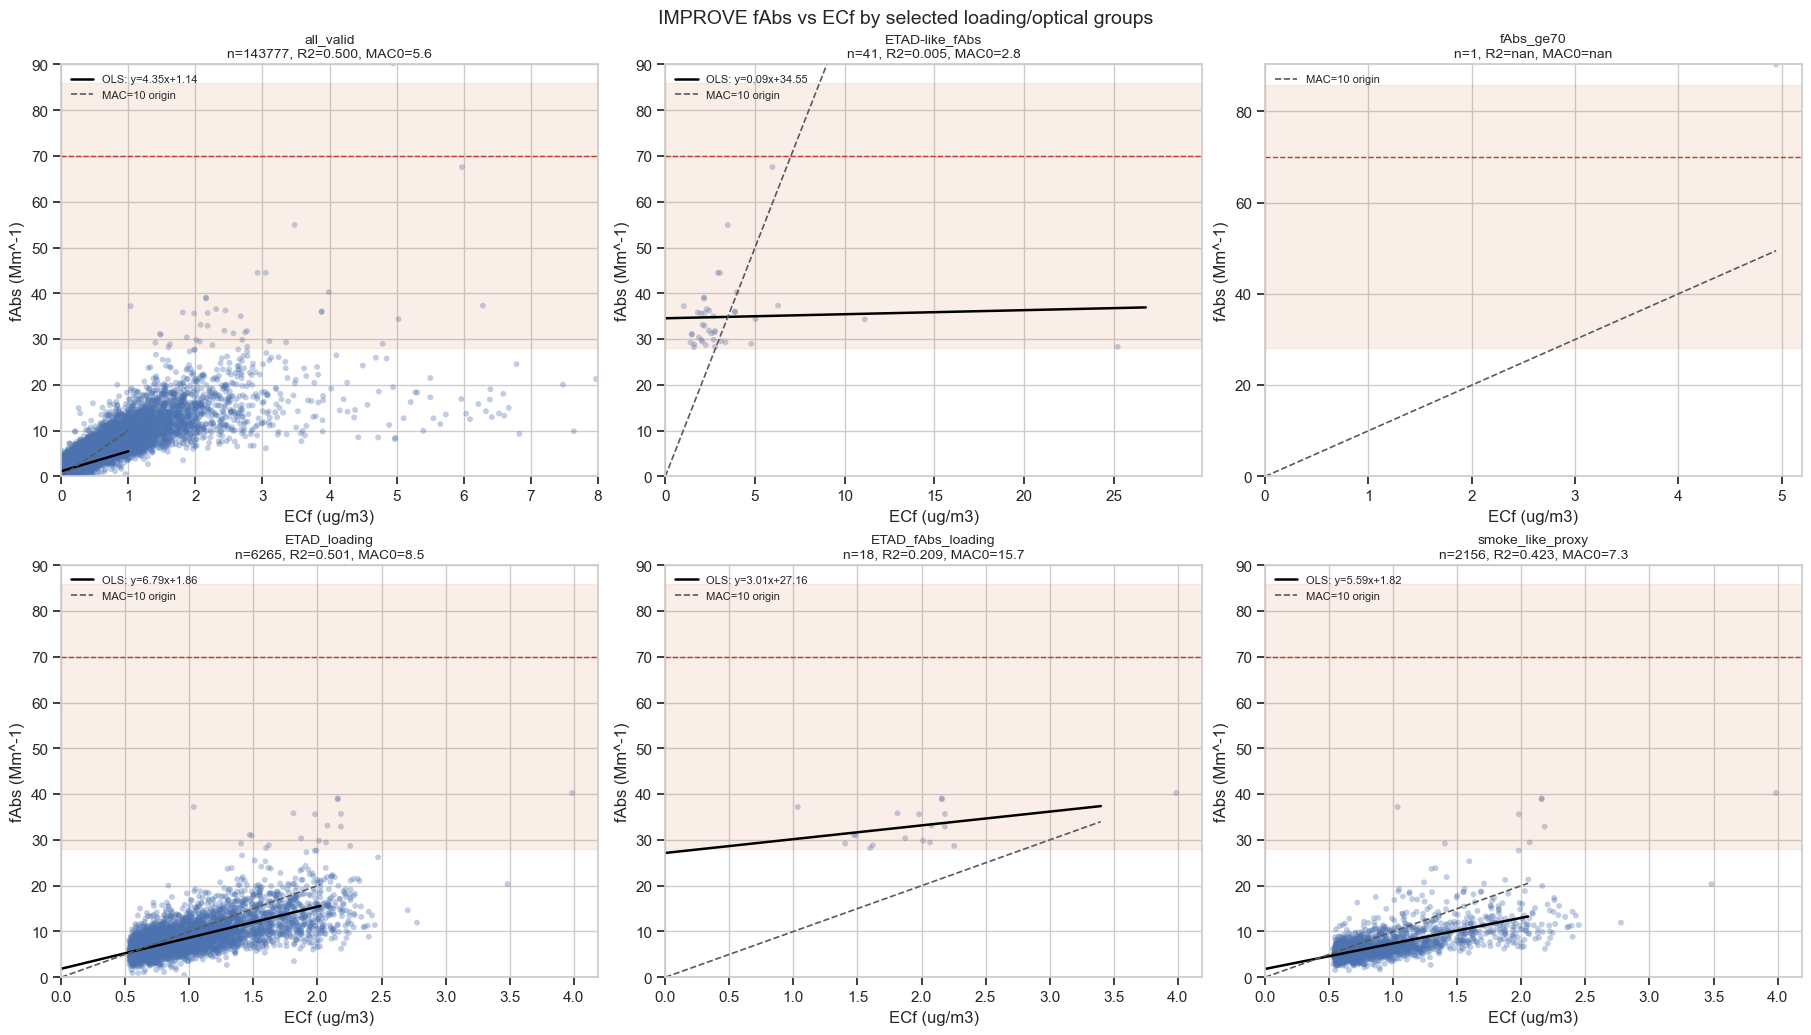

In [7]:
def regression_report(df: pd.DataFrame, x_col='ECf_Val', y_col='fAbs_Val', n_boot=1000) -> dict:
    pair = df[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()
    pair = pair[(pair[x_col] > 0) & (pair[y_col] > 0)]
    n = len(pair)
    out = {'n': n, 'slope': np.nan, 'intercept': np.nan, 'R2': np.nan, 'MAC_origin': np.nan,
           'slope_ci_low': np.nan, 'slope_ci_high': np.nan, 'intercept_ci_low': np.nan, 'intercept_ci_high': np.nan}
    if n < 3:
        return out
    x = pair[x_col].to_numpy(float)
    y = pair[y_col].to_numpy(float)
    slope, intercept = np.polyfit(x, y, 1)
    r2 = float(np.corrcoef(x, y)[0, 1] ** 2)
    mac = float(np.sum(x * y) / np.sum(x ** 2))
    out.update({'slope': slope, 'intercept': intercept, 'R2': r2, 'MAC_origin': mac})
    if n >= 10 and n_boot:
        slopes = np.empty(n_boot)
        intercepts = np.empty(n_boot)
        idx = np.arange(n)
        for i in range(n_boot):
            sample_idx = RNG.choice(idx, size=n, replace=True)
            xb = x[sample_idx]
            yb = y[sample_idx]
            slopes[i], intercepts[i] = np.polyfit(xb, yb, 1)
        out.update({
            'slope_ci_low': np.quantile(slopes, 0.025),
            'slope_ci_high': np.quantile(slopes, 0.975),
            'intercept_ci_low': np.quantile(intercepts, 0.025),
            'intercept_ci_high': np.quantile(intercepts, 0.975),
        })
    return out

reg_rows = []
for name, mask in group_defs.items():
    g = valid[mask].copy()
    stats = regression_report(g)
    stats['group'] = name
    stats['sites'] = g['SiteCode'].nunique()
    stats['date_start'] = g['Date'].min()
    stats['date_end'] = g['Date'].max()
    stats['median_EC_loading_ug_cm2_3p53'] = g['EC_loading_ug_cm2_3p53'].median()
    stats['median_OC_EC'] = g['OC_EC'].median()
    stats['median_TransM_deficit_pct'] = g['TransM_deficit_frac'].median() * 100
    reg_rows.append(stats)
regression_summary = pd.DataFrame(reg_rows)[[
    'group', 'n', 'sites', 'slope', 'slope_ci_low', 'slope_ci_high', 'intercept', 'intercept_ci_low', 'intercept_ci_high',
    'R2', 'MAC_origin', 'median_EC_loading_ug_cm2_3p53', 'median_OC_EC', 'median_TransM_deficit_pct', 'date_start', 'date_end'
]]
regression_summary.to_csv(OUTPUT_DIR / 'improve_fabs_ec_regression_summary.csv', index=False)

print('fAbs vs ECf regression summary:')
display(regression_summary.round(3))

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=False, sharey=False, constrained_layout=True)
for ax, (name, mask) in zip(axes.ravel(), group_defs.items()):
    g = valid[mask].copy()
    if len(g) == 0:
        ax.set_title(name + ' (empty)')
        continue
    ax.scatter(g['ECf_Val'], g['fAbs_Val'], s=18, color='#4c72b0', alpha=0.35, edgecolor='none')
    stats = regression_report(g, n_boot=0)
    x_max = max(1, g['ECf_Val'].quantile(0.98))
    x = np.linspace(0, x_max, 100)
    if np.isfinite(stats['slope']):
        ax.plot(x, stats['slope'] * x + stats['intercept'], color='black', lw=1.8,
                label=f"OLS: y={stats['slope']:.2f}x+{stats['intercept']:.2f}")
    ax.plot(x, 10 * x, color='0.35', lw=1.2, ls='--', label='MAC=10 origin')
    ax.axhspan(ETAD_FABS_LOW, ETAD_FABS_HIGH, color='#dd8452', alpha=0.13)
    ax.axhline(HIGH_TAIL_FABS, color='#c0392b', ls='--', lw=1)
    ax.set_xlim(0, min(max(8, g['ECf_Val'].quantile(0.99)), g['ECf_Val'].max() * 1.05))
    ax.set_ylim(0, max(90, min(g['fAbs_Val'].quantile(0.995), 140)))
    ax.set_title(f"{name}\nn={int(stats['n'])}, R2={stats['R2']:.3f}, MAC0={stats['MAC_origin']:.1f}", fontsize=10)
    ax.set_xlabel('ECf (ug/m3)')
    ax.set_ylabel('fAbs (Mm^-1)')
    ax.legend(fontsize=8, loc='upper left')

fig.suptitle('IMPROVE fAbs vs ECf by selected loading/optical groups', fontsize=14, y=1.02)
fig.savefig(OUTPUT_DIR / 'improve_fabs_ec_group_regressions.png', dpi=220, bbox_inches='tight')
plt.show()

## 8. Top candidates and context tables

These tables identify the exact site/date rows to request raw HIPS data for if we want the true White-style blank-regression comparison.

In [8]:
context_cols = [
    'SiteCode', 'SiteName', 'Country', 'State', 'Date', 'POC', 'AuxID',
    'fAbs_Val', 'ECf_Val', 'OCf_Val', 'MF_Val', 'FEf_Val', 'SOILf_Val',
    'volume_m3', 'EC_loading_ug', 'EC_loading_ug_cm2_3p53', 'OC_EC', 'FE_EC', 'SOIL_EC',
    'RefI_635_Val', 'TransI_635_Val', 'RefM_635_Val', 'TransM_635_Val', 'RefF_635_Val', 'TransF_635_Val',
    'TransM_deficit_frac', 'rt_tau_proxy_M', 'TransM_over_TransI', 'RefM_over_RefI'
]
context_cols = [c for c in context_cols if c in valid.columns]

top_fabs = valid.sort_values('fAbs_Val', ascending=False).head(50)[context_cols]
top_deficit = valid.sort_values('TransM_deficit_frac', ascending=False).head(50)[context_cols]
etad_like_candidates = valid[valid['group_etad_fabs']].sort_values(['fAbs_Val', 'EC_loading_ug_cm2_3p53'], ascending=False).head(100)[context_cols]
smoke_candidates = valid[valid['group_smoke_like_proxy']].sort_values(['fAbs_Val', 'TransM_deficit_frac'], ascending=False).head(100)[context_cols]

site_date_counts = (
    valid[valid['group_etad_fabs'] | valid['group_high_tail_ge70'] | valid['group_smoke_like_proxy']]
    .assign(year=lambda d: d['Date'].dt.year)
    .groupby(['SiteCode', 'SiteName', 'State', 'year'], dropna=False)
    .agg(n=('SiteCode', 'size'), max_fAbs=('fAbs_Val', 'max'), median_fAbs=('fAbs_Val', 'median'),
         median_EC=('ECf_Val', 'median'), median_OC_EC=('OC_EC', 'median'), median_deficit_pct=('TransM_deficit_frac', lambda s: s.median() * 100))
    .reset_index()
    .sort_values(['max_fAbs', 'n'], ascending=False)
)

for name, df in {
    'improve_top_fabs_candidates.csv': top_fabs,
    'improve_top_rt_deficit_candidates.csv': top_deficit,
    'improve_etad_like_candidates.csv': etad_like_candidates,
    'improve_smoke_like_proxy_candidates.csv': smoke_candidates,
    'improve_site_year_context.csv': site_date_counts,
}.items():
    df.to_csv(OUTPUT_DIR / name, index=False)

print('Top fAbs candidates:')
display(top_fabs.head(15).round(3))
print('Top RT-deficit candidates:')
display(top_deficit.head(15).round(3))
print('Site/year context for highlighted rows:')
display(site_date_counts.head(25).round(3))

Top fAbs candidates:


,SiteCode,SiteName,Country,State,Date,POC,AuxID,fAbs_Val,ECf_Val,OCf_Val,MF_Val,FEf_Val,SOILf_Val,volume_m3,EC_loading_ug,EC_loading_ug_cm2_3p53,OC_EC,FE_EC,SOIL_EC,RefI_635_Val,TransI_635_Val,RefM_635_Val,TransM_635_Val,RefF_635_Val,TransF_635_Val,TransM_deficit_frac,rt_tau_proxy_M,TransM_over_TransI,RefM_over_RefI
121182,PHOE1,Phoenix,US,AZ,2022-12-25,1,0,90.26,4.946,12.033,88.356,0.283,2.864,21.655,107.099,30.340,2.433,0.057,0.579,98.94,1.15,98.59,0.08,274.32,234.23,0.999,2.665,0.070,0.996
122103,PHOE5,Phoenix Colocated Sampler,US,AZ,2021-01-01,2,0,67.58,5.975,28.938,155.110,0.385,4.999,24.338,145.417,41.195,4.843,0.064,0.837,93.48,1.53,88.13,0.71,227.04,275.58,0.992,0.768,0.464,0.943
122590,PHOE5,Phoenix Colocated Sampler,US,AZ,2025-01-01,2,0,54.93,3.480,13.050,83.851,0.300,3.732,30.233,105.213,29.806,3.750,0.086,1.072,244.15,2.86,237.81,0.81,471.73,179.31,0.994,1.262,0.283,0.974
110858,NOGA1,Nogales,US,AZ,2024-01-10,1,0,44.48,2.928,6.555,37.287,0.175,3.330,24.206,70.871,20.077,2.239,0.060,1.137,154.85,5.42,147.43,1.07,404.43,279.38,0.990,1.622,0.197,0.952
110987,NOGA1,Nogales,US,AZ,2025-01-31,1,0,44.48,3.049,4.778,29.283,0.229,5.110,24.740,75.438,21.371,1.567,0.075,1.676,411.87,1.74,406.11,0.76,558.50,101.66,0.996,0.828,0.437,0.986
160320,SYCA2,Sycamore Canyon,US,AZ,2023-11-02,1,0,40.27,3.989,47.563,127.986,0.545,4.701,16.640,66.371,18.802,11.925,0.137,1.179,213.93,18.75,196.14,5.29,480.81,298.91,0.958,1.265,0.282,0.917
149088,SHMI1,Shamrock Mine,US,CO,2024-04-24,1,0,39.10,2.158,30.484,165.338,0.084,1.599,15.966,34.449,9.759,14.128,0.039,0.741,530.63,14.01,500.22,0.50,703.26,217.61,0.998,3.333,0.036,0.943
78705,KALM1,Kalmiopsis,US,OR,2020-09-12,1,0,38.91,33.029,55.807,183.188,0.211,2.370,27.605,911.759,258.289,1.690,0.006,0.072,162.10,1.52,154.21,0.34,364.29,188.51,0.997,1.498,0.224,0.951
110973,NOGA1,Nogales,US,AZ,2024-12-20,1,0,38.86,2.159,13.035,39.719,0.757,14.189,29.768,64.278,18.209,6.037,0.351,6.571,192.86,0.46,168.43,0.01,476.17,209.53,1.000,3.829,0.022,0.873
138770,SAGO1,San Gorgonio Wilderness,US,CA,2024-09-12,1,0,37.32,6.286,107.201,144.182,0.204,3.090,14.053,88.342,25.026,17.053,0.032,0.491,225.95,14.78,193.36,0.65,585.28,185.80,0.995,3.124,0.044,0.856


Top RT-deficit candidates:


,SiteCode,SiteName,Country,State,Date,POC,AuxID,fAbs_Val,ECf_Val,OCf_Val,MF_Val,FEf_Val,SOILf_Val,volume_m3,EC_loading_ug,EC_loading_ug_cm2_3p53,OC_EC,FE_EC,SOIL_EC,RefI_635_Val,TransI_635_Val,RefM_635_Val,TransM_635_Val,RefF_635_Val,TransF_635_Val,TransM_deficit_frac,rt_tau_proxy_M,TransM_over_TransI,RefM_over_RefI
92779,MAVI1,Martha's Vineyard,US,MA,2023-09-06,1,0,5.71,0.738,5.465,18.279,0.058,0.709,30.974,22.856,6.475,7.406,0.079,0.961,357.61,118.05,285.71,0.01,566.02,355.21,1.0,9.376,0.000,0.799
52478,FRRE1,Frostburg Reservoir (Big Piney Run),US,MD,2023-06-17,1,0,3.98,0.642,6.675,18.989,0.018,0.172,28.739,18.459,5.229,10.393,0.028,0.269,318.89,73.44,267.53,0.01,396.77,176.82,1.0,8.902,0.000,0.839
28374,CAVE1,Carlsbad Caverns,US,NM,2023-05-21,1,0,3.93,0.509,2.695,9.098,0.019,0.391,30.679,15.611,4.422,5.296,0.037,0.769,246.21,66.39,187.84,0.01,324.66,121.66,1.0,8.801,0.000,0.763
18020,BRIG1,Brigantine NWR,US,NJ,2019-12-23,1,0,5.94,0.922,3.660,9.326,0.089,0.489,29.974,27.640,7.830,3.969,0.096,0.530,221.72,65.59,184.85,0.01,398.62,336.47,1.0,8.789,0.000,0.834
47000,FLAT1,Flathead,US,MT,2018-08-21,1,0,7.35,1.093,13.038,30.397,0.043,0.693,28.554,31.196,8.837,11.934,0.039,0.634,211.63,84.03,169.95,0.01,318.58,215.99,1.0,9.036,0.000,0.803
110973,NOGA1,Nogales,US,AZ,2024-12-20,1,0,38.86,2.159,13.035,39.719,0.757,14.189,29.768,64.278,18.209,6.037,0.351,6.571,192.86,0.46,168.43,0.01,476.17,209.53,1.0,3.829,0.022,0.873
34755,CRLA1,Crater Lake NP,US,OR,2018-08-09,1,0,16.90,18.022,34.932,107.226,0.077,0.789,28.454,512.797,145.268,1.938,0.004,0.044,82.65,14.72,81.48,0.01,170.96,124.91,1.0,7.294,0.001,0.986
86919,LOST1,Lostwood,US,ND,2023-05-24,1,0,4.20,0.598,3.915,12.733,0.066,1.141,31.547,18.880,5.349,6.541,0.110,1.907,114.10,40.68,79.77,0.01,166.91,83.83,1.0,8.311,0.000,0.699
170658,UPBU1,Upper Buffalo Wilderness,US,AR,2023-03-19,1,0,3.07,0.738,6.258,13.887,0.022,0.403,28.667,21.144,5.990,8.485,0.030,0.547,81.13,15.43,60.55,0.01,110.28,37.00,1.0,7.341,0.001,0.746
130749,QUCI1,Quaker City,US,OH,2025-05-16,1,0,3.39,0.228,1.666,8.963,0.073,1.389,31.018,7.085,2.007,7.293,0.320,6.080,389.20,30.10,302.83,0.02,480.88,49.72,1.0,7.317,0.001,0.778


Site/year context for highlighted rows:


,SiteCode,SiteName,State,year,n,max_fAbs,median_fAbs,median_EC,median_OC_EC,median_deficit_pct
489,PHOE1,Phoenix,AZ,2022,1,90.26,90.260,4.946,2.433,99.916
492,PHOE5,Phoenix Colocated Sampler,AZ,2021,1,67.58,67.580,5.975,4.843,99.228
494,PHOE5,Phoenix Colocated Sampler,AZ,2025,1,54.93,54.930,3.480,3.750,99.413
452,NOGA1,Nogales,AZ,2024,5,44.48,35.820,2.700,2.239,99.029
453,NOGA1,Nogales,AZ,2025,1,44.48,44.480,3.049,1.567,99.599
644,SYCA2,Sycamore Canyon,AZ,2023,3,40.27,20.360,3.483,9.552,95.772
586,SHMI1,Shamrock Mine,CO,2024,2,39.10,21.980,1.661,15.945,98.340
319,KALM1,Kalmiopsis,OR,2020,6,38.91,5.735,1.067,7.662,96.870
552,SAGO1,San Gorgonio Wilderness,CA,2024,3,37.32,11.430,1.866,11.046,99.477
104,CACR1,Caney Creek,AR,2024,3,37.20,5.490,0.694,6.076,97.888


## 9. Answer for the Addis/IMPROVE fork

Use this notebook as a **screening and request-generation notebook**, not as final proof of the White mechanism.

### What this analysis can say

- The exact field-blank calibration plot from White et al. cannot be recreated from this FED pull because explicit blank rows are not exported.
- The initial RT line provides a useful FED-level analog: high-`fAbs` filters are visibly displaced from the clean-filter initial relationship.
- The small `fAbs >= 70` group is too sparse for a stable regression by itself, so broader characteristic screens matter more than the hard high-tail threshold.
- Candidate site/date rows are now identified for a raw HIPS request.

### What would confirm the fork

Ask Alex/Cena/IMPROVE for the raw HIPS records corresponding to the candidate filters exported here, including field blanks and the actual blank-regression coefficients used. Then reproduce the exact SPARTAN/White-style plot with true blank lines rather than the FED initial-line analog.

## 10. Files written

In [9]:
written = sorted(OUTPUT_DIR.glob('*'))
for path in written:
    print(path)

/Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/output/white_style_rt_calibration_space/improve_etad_like_candidates.csv
/Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/output/white_style_rt_calibration_space/improve_fabs_ec_group_regressions.png
/Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/output/white_style_rt_calibration_space/improve_fabs_ec_regression_summary.csv
/Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/output/white_style_rt_calibration_space/improve_initial_rt_line_fit.csv
/Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/output/white_style_rt_calibration_space/improve_joined_rt_chem_with_diagnostics.pkl
/Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/output/white_style_rt_calibration_space/improve_rt_group_summary.csv
/Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/output/white_style_rt_calibration_space/improve_site_year_context.csv
/Users/ahmadj